In [119]:
import numpy as np 
import pandas as pd
import os

from obspy.clients.fdsn import Client
from obspy import UTCDateTime
from obspy import read_inventory
from obspy.geodetics import gps2dist_azimuth
from obspy.core import UTCDateTime

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [168]:
def plot_inventory(inv):
    """
    Plot seismic stations from an ObsPy Inventory object on a map.
    The map extent will be dynamically adjusted based on the input inventory's range of latitudes and longitudes.
    Each network will be plotted in a different color.

    Parameters:
    - inv: ObsPy Inventory object containing station metadata.
    """
    import matplotlib.cm as cm
    
    # Extract station coordinates and network information
    lats, lons, networks = [], [], []
    for net in inv:
        for sta in net:
            try:
                lats.append(sta.latitude)
                lons.append(sta.longitude)
                networks.append(net.code)  # Network code for coloring
            except:
                pass  # Skip stations with missing coordinates

    # Determine map extent based on station coordinates
    lat_min, lat_max = np.min(lats), np.max(lats)
    lon_min, lon_max = np.min(lons), np.max(lons)


    # Add some padding around the map extent
    padding = 0.5
    lat_min -= padding
    lat_max += padding
    lon_min -= padding
    lon_max += padding

    # Create the map
    fig = plt.figure(figsize=(10, 8))
    ax = plt.axes(projection=ccrs.PlateCarree())

    # Set dynamic extent based on the latitude and longitude range
    ax.set_extent([lon_min, lon_max, lat_min, lat_max])

    # Add map features
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.STATES, linestyle='-')
    ax.add_feature(cfeature.BORDERS, linestyle='-')
    ax.gridlines(draw_labels=True)
    # Draw lakes
    ax.add_feature(cfeature.LAKES, alpha=0.5)

    # Create a color map based on unique networks
    unique_networks = list(set(networks))
    network_colors = cm.get_cmap('tab20', len(unique_networks))  # Use a colormap with enough distinct colors

    # Plot stations by network with different colors, with the number of station in the label
    for i, network in enumerate(unique_networks):
        network_lats = [lats[j] for j in range(len(networks)) if networks[j] == network]
        network_lons = [lons[j] for j in range(len(networks)) if networks[j] == network]
        
        ax.scatter(network_lons, network_lats, c=[network_colors(i)], s=30, marker='^', label=f"{network} ({len(network_lats)})")

    plt.title("Seismic Stations in Inventory")
    plt.legend(title="Network")
    plt.show()

def inventory_to_dataframe(inventory):
    # Lists to hold the extracted data
    networks = []
    stations = []
    locations = []
    channels = []
    slats = []
    slons = []
    seles = []
    sampling_rates = []
    units = []

    for network in inventory:
        for station in network:
            for channel in station:
                networks.append(network.code)
                stations.append(station.code)
                locations.append(channel.location_code)
                channels.append(channel.code)
                slats.append(station.latitude)
                slons.append(station.longitude)
                seles.append(station.elevation)
                sampling_rates.append(channel.sample_rate)
                try:
                    units.append(channel.response.instrument_sensitivity.input_units)
                except:
                    units.append("")
                    print(f"Missing instrument sensitivity for {network.code}.{station.code}.{channel.location_code}.{channel.code}")
    
    # Creating the DataFrame
    df = pd.DataFrame({
        'net': networks,
        'sta': stations,
        'loc': locations,
        'cha': channels,
        'slat': slats,
        'slon': slons,
        'sele': seles,
        'sampling_rate': sampling_rates,
        'units': units
    })
    df['direction'] = df['cha'].str[-1]
    df['sname'] = df.apply(lambda row: f"{row['net']}.{row['sta']}.{row['loc']}.{row['cha']}", axis=1)
    return df

# Function to remove stations from inventory based on filtered DataFrame
def filter_inventory_by_dataframe(inv, inv_df):

    # first, get a list of all full station names in inv
    full_station_names = []
    for net in inv:
        for sta in net:
            for cha in sta:
                full_station_names.append(f"{net.code}.{sta.code}.{cha.location_code}.{cha.code}")
    # print(full_station_names)

    # then, check if each element is in inv_df['sname']. If not, remove it from inv
    for name in full_station_names:
        if name not in inv_df['sname'].values:
            net, sta, loc, cha = name.split('.')
            inv = inv.remove(net, sta, loc, cha, keep_empty=False)
    
    return inv

def download_responses(inv, client, startdate, enddate, output_dir):
    """
    Downloads and saves response information for each station/channel in the inventory.
    
    Parameters:
    - inv: ObsPy Inventory object with filtered stations and channels.
    - client: ObsPy FDSN client (e.g., Client("SCEDC"))
    - output_dir: Directory to save individual response files
    """
    os.makedirs(output_dir, exist_ok=True)

    for net in inv:
        for sta in net:
            for cha in sta:
                # Extract metadata
                network = net.code
                station = sta.code
                location = cha.location_code
                channel = cha.code
                # starttime = cha.start_date
                # endtime = cha.end_date
                
                # Build a filename
                loc_code = location if location else ""
                filename = f"{network}.{station}.{loc_code}.{channel}.xml"
                filepath = os.path.join(output_dir, filename)
                # print("location, loc_code: ", location, loc_code)
                # Skip if already exists
                if os.path.exists(filepath):
                    continue

                try:
                    # Request full station info with response
                    response_inv = client.get_stations(
                        network=network,
                        station=station,
                        starttime=startdate,
                        endtime=enddate,
                        level="response"
                    )
                    # select only the channel we want
                    response_inv = response_inv.select(
                        network=network,
                        station=station,
                        location=location,
                        channel=channel
                    )
                    response_inv.write(filepath, format="STATIONXML")
                    print(f"Saved response: {filename}")
                except Exception as e:
                    print(f"Failed to get response for {filename}: {e}")

In [138]:
inv2 = read_inventory("/Users/ivandevert/prog/spectral-falloff-ratio/testing/projects/example_salton_sea/metadata/stations/AZ.BZN..HHZ.xml")

inv2[0][0]

Station BZN (Buzz Northerns Place, Anza, CA, USA)
	Station Code: BZN
	Channel Count: None/None (Selected/Total)
	1983-01-20T00:00:00.000000Z - 3000-01-01T00:00:00.000000Z
	Access: None 
	Latitude: 33.4915, Longitude: -116.6670, Elevation: 1301.0 m
	Available Channels:


In [ ]:
inventory[0].plot_response(min_freq=1E-4)

Map extent: 32.41 to 34.20, -116.89 to -114.70
Map extent with padding: 31.91 to 34.70, -117.39 to -114.20


/var/folders/n9/y3b20y1x2dx7n3qq1qn2cn2m000jzz/T/ipykernel_21679/2659336548.py:54: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  network_colors = cm.get_cmap('tab20', len(unique_networks))  # Use a colormap with enough distinct colors


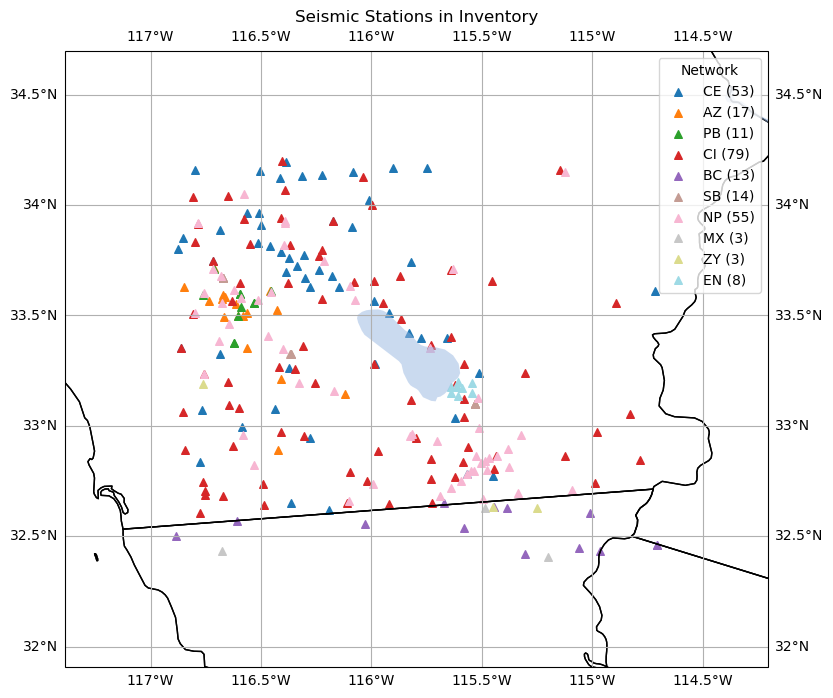

cha
HNZ    339
HNE    331
HNN    331
HHZ    107
HHE     99
HHN     99
EHZ     47
EH2     16
HN2      9
EH1      8
EH3      8
HH2      8
HN1      8
HH1      8
HN3      2
ENZ      1
ENN      1
ENE      1
HJE      1
HJN      1
HJZ      1
EHE      1
EHN      1
Name: count, dtype: int64

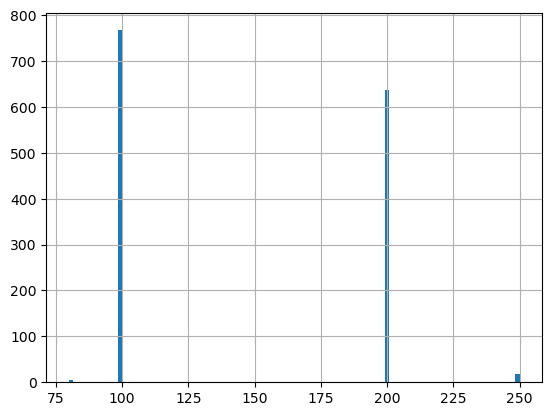

In [ ]:


client = Client("SCEDC")
project_dir = "/Users/ivandevert/prog/spectral-falloff-ratio/testing/projects/example_salton_sea/"
# Define region and time window for all events you care about
starttime = UTCDateTime("2020-01-01")
endtime = UTCDateTime("2020-12-31")

latrange = [32.4,34.2]
lonrange = [-116.9, -114.7]

allowed_sampling_rates = [100.0, 200.0, 80.0, 250.0]
allowed_directions = ["Z", "N", "E", "1", "2", "3"]

# if station_inventory.xml doesn't exist, download it
if not os.path.exists(f"{project_dir}metadata/station_inventory.xml"):
    inv = client.get_stations(
        network="*",  # or "SC" or leave blank for all
        starttime=starttime,
        endtime=endtime,
        minlatitude=latrange[0],
        maxlatitude=latrange[1],
        minlongitude=lonrange[0],
        maxlongitude=lonrange[1],
        level="channel"
    )

    inv_df = inventory_to_dataframe(inv)

    # filter inv_df by sampling rate. if sampling rate is not in allowed_sampling_rates, drop the row
    inv_df = inv_df[inv_df["sampling_rate"].isin(allowed_sampling_rates)]

    # filter inv_df by direction. if direction is not in allowed_directions, drop the row
    inv_df = inv_df[inv_df["direction"].isin(allowed_directions)]


    inv = filter_inventory_by_dataframe(inv, inv_df)

    inv.write(f"{project_dir}metadata/station_inventory.xml", format="STATIONXML")
else:
    # Load from file or use `inv` from earlier
    inv = read_inventory(f"{project_dir}metadata/station_inventory.xml")

plot_inventory(inv)
# make a histogram of sampling rates
inv_df["sampling_rate"].hist(bins=100)
# print out all sampling rates and their counts
inv_df["sampling_rate"].value_counts()
# make a histogram of channel names (inv_df["cha"])
inv_df["cha"].value_counts()

In [170]:
download_responses(inv, client, starttime, endtime, f"{project_dir}metadata/stations/")

Saved response: AZ.BZN..HHE.xml
Saved response: AZ.BZN..HHN.xml
Saved response: AZ.BZN..HHZ.xml
Saved response: AZ.BZN..HNE.xml
Saved response: AZ.BZN..HNN.xml
Saved response: AZ.BZN..HNZ.xml
Saved response: AZ.CRY..HHE.xml
Saved response: AZ.CRY..HHN.xml
Saved response: AZ.CRY..HHZ.xml
Saved response: AZ.CRY..HNE.xml
Saved response: AZ.CRY..HNN.xml
Saved response: AZ.CRY..HNZ.xml
Saved response: AZ.FRD..HHE.xml
Saved response: AZ.FRD..HHN.xml
Saved response: AZ.FRD..HHZ.xml
Saved response: AZ.FRD..HNE.xml
Saved response: AZ.FRD..HNN.xml
Saved response: AZ.FRD..HNZ.xml
Saved response: AZ.GARR..HNE.xml
Saved response: AZ.GARR..HNN.xml
Saved response: AZ.GARR..HNZ.xml
Saved response: AZ.HSSP..HNE.xml
Saved response: AZ.HSSP..HNN.xml
Saved response: AZ.HSSP..HNZ.xml
Saved response: AZ.KNW..HHE.xml
Saved response: AZ.KNW..HHN.xml
Saved response: AZ.KNW..HHZ.xml
Saved response: AZ.KNW..HNE.xml
Saved response: AZ.KNW..HNN.xml
Saved response: AZ.KNW..HNZ.xml
Saved response: AZ.LVA2..HHE.xml
S

In [158]:
network = "AZ"
station = "BZN"
location = ""
channel = "HHZ"

response_inv = client.get_stations(
    network=network,
    station=station,
    # location="*",
    # channel="*",
    starttime=starttime,
    endtime=endtime,
    level="response"
)
# select only the channel we want
response_inv = response_inv.select(
    network=network,
    station=station,
    location=location,
    channel=channel
)

response_inv.write(f"{project_dir}metadata/stations/AZ.BZN..HHZ.xml", format="STATIONXML")

In [166]:
response_inv[0][0][0].start_date

2013-10-22T19:30:00.000000Z

In [148]:
response_inv.write(f"{project_dir}metadata/stations/AZ.BZN..HHZ.xml", format="STATIONXML")

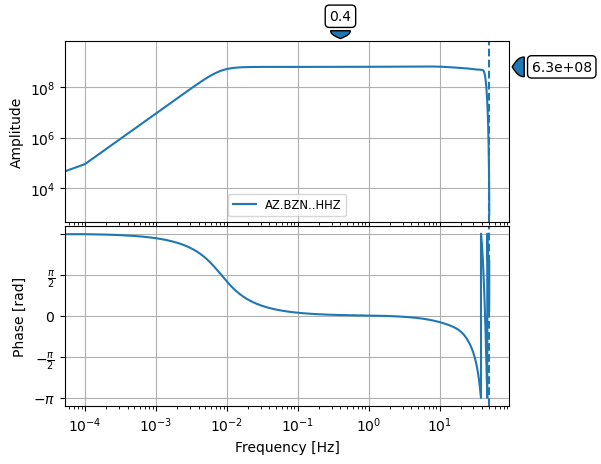

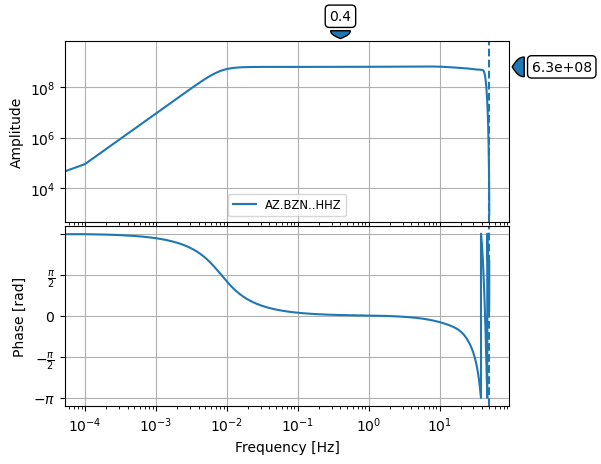

In [142]:
response_inv.plot_response(min_freq=1E-4)

In [132]:
response_inv[0][0][0].response

Channel Response
	From M/S (VELOCITY in Meters per second) to COUNTS (Digital Counts)
	Overall Sensitivity: 6.29919e+08 defined at 0.400 Hz
	3 stages:
		Stage 1: PolesZerosResponseStage from M/S to V, gain: 1501.85
		Stage 2: CoefficientsTypeResponseStage from V to COUNTS, gain: 419430
		Stage 3: FIRResponseStage from COUNTS to COUNTS, gain: 1